
TFG

Este es el codigo del tfg de Borja Jimeno

In [3]:

import uproot
def carga_datos_hist():
    file = uproot.open("/home/borja/Documents/TFG/Datos/BEhistos_year123456.root")
    file.keys()
    longitud=290
    es=np.arange(1,30,0.1)
    datos=np.zeros((19,longitud))
    for i in range (9):
        datos[2*i+1]=file["hbea_123456y_D"+str(i)].values()
        datos[2*i+2]=file["hbea_123456y_D"+str(i)].errors()
    datos[0]=es
    return datos
    #np.savetxt("Exposicion_exp.csv",datos)   
    

Imprimimos los histogramas con *matplotlib*

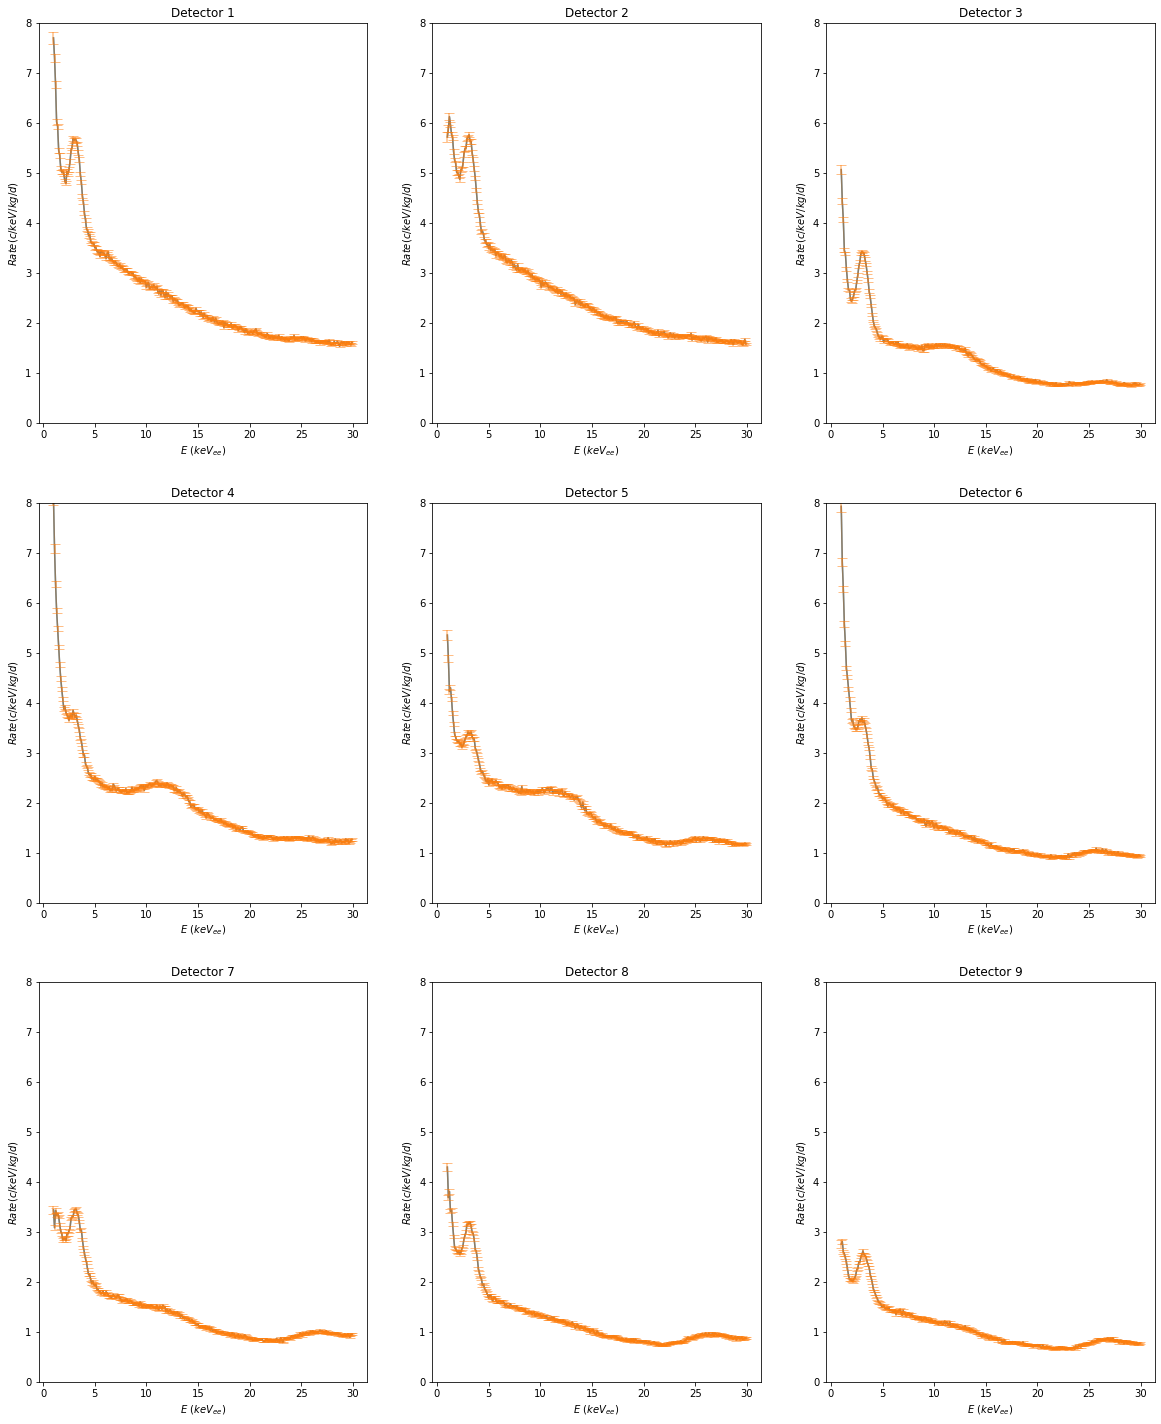

In [4]:
import numpy as np
import matplotlib.pyplot as plt

datos=carga_datos_hist()


fig, axes = plt.subplots(3, 3, figsize=(20, 25))

k=int(0)
for i in range(3):
    for j in range(3):
        axes[i, j].plot(datos[0], datos[2*k+1])
        axes[i, j].errorbar(datos[0], datos[2*k+1], yerr=datos[2*k+2], fmt='', capsize=5, alpha=0.5)
        axes[i, j].set_title(f"Detector {k+1}")
        axes[i, j].set_ylim(0,8)
        axes[i, j].set_ylabel(r'$Rate (c/keV/kg/d)$')
        axes[i, j].set_xlabel(r'$E$ ($keV_{ee}$)')
        k=k+1


plt.show()

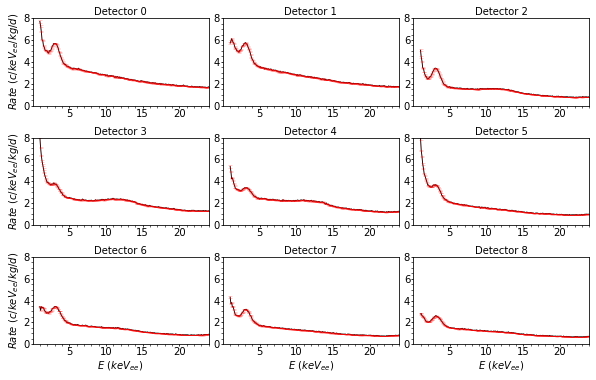

In [5]:
datos = carga_datos_hist()

# Media hoja A4 apaisada: ~21 x 14.85 cm → pulgadas: 8.27 x 5.85
fig, axes = plt.subplots(3, 3, figsize=(8, 5))

# Tamaños de fuente compactos pero legibles
TITLE_SIZE = 10
LABEL_SIZE = 10
TICK_SIZE  = 10

k = 0
for i in range(3):
    for j in range(3):
        ax=axes[i,j]
        ax.minorticks_on()
        ax = axes[i, j]
        ax.plot(datos[0], datos[2*k+1], linewidth=0.9, color="black")
        ax.errorbar(datos[0], datos[2*k+1], yerr=datos[2*k+2],
                    fmt='', capsize=2, alpha=0.2, linewidth=0.6, color="red")
        ax.set_title(f"Detector {k}", fontsize=TITLE_SIZE, pad=3)
        ax.set_ylim(0, 8)
        ax.set_xlim(0.01, 24)
       
        ax.tick_params(axis='both', labelsize=TICK_SIZE, length=2, pad=1)
        plt.tight_layout(pad=0.5, h_pad=0.8, w_pad=0.5)
        k += 1
axes[0,0].set_ylabel(r'$Rate\ (c/keV_{ee}/kg/d)$', fontsize=LABEL_SIZE, labelpad=2)
axes[1,0].set_ylabel(r'$Rate\ (c/keV_{ee}/kg/d)$', fontsize=LABEL_SIZE, labelpad=2)
axes[2,0].set_ylabel(r'$Rate\ (c/keV_{ee}/kg/d)$', fontsize=LABEL_SIZE, labelpad=2)
axes[2,0].set_xlabel(r'$E\ (keV_{ee})$',       fontsize=LABEL_SIZE, labelpad=2)
axes[2,1].set_xlabel(r'$E\ (keV_{ee})$',       fontsize=LABEL_SIZE, labelpad=2)
axes[2,2].set_xlabel(r'$E\ (keV_{ee})$',       fontsize=LABEL_SIZE, labelpad=2)

plt.savefig("Ritmo_por_detector.pdf", bbox_inches='tight')
plt.show()